In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kolawale/focusing-on-mobile-app-or-website")

print("Path to dataset files:", path)

/Users/shubham/Desktop/ML_REPO/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/shubham/.cache/kagglehub/datasets/kolawale/focusing-on-mobile-app-or-website/versions/1


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(path + "/Ecommerce Customers")

# EDA

In [6]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [7]:
df.isna().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [9]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


<b> Dropping irrelevant columns

In [10]:
data = df.drop(columns=['Email', 'Address', 'Avatar'])

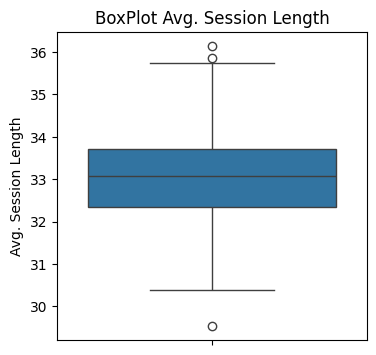

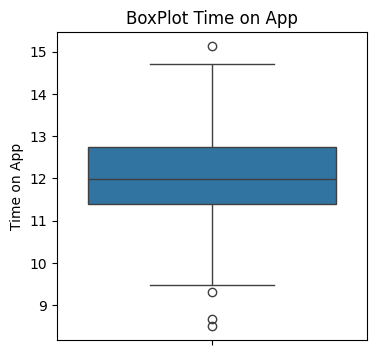

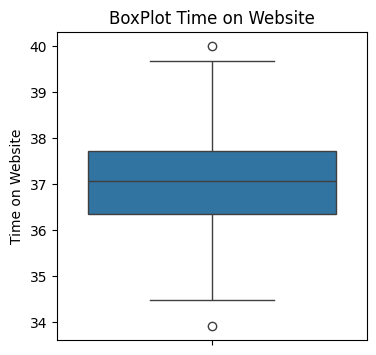

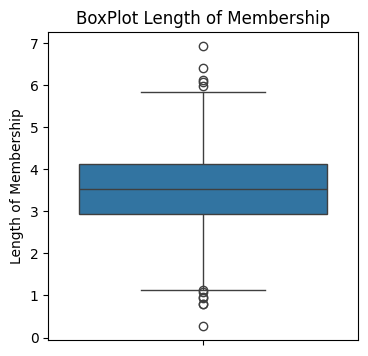

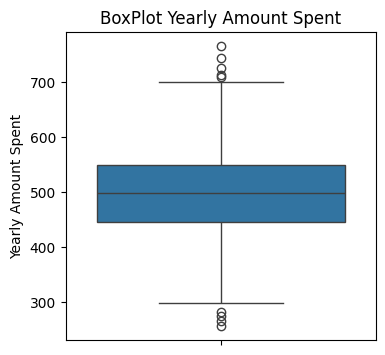

In [11]:
for col in data.columns:
    ax, fig= plt.subplots( figsize=(4, 4) )
    sns.boxplot(data[col])
    plt.title(f"BoxPlot {col}")
    plt.show()

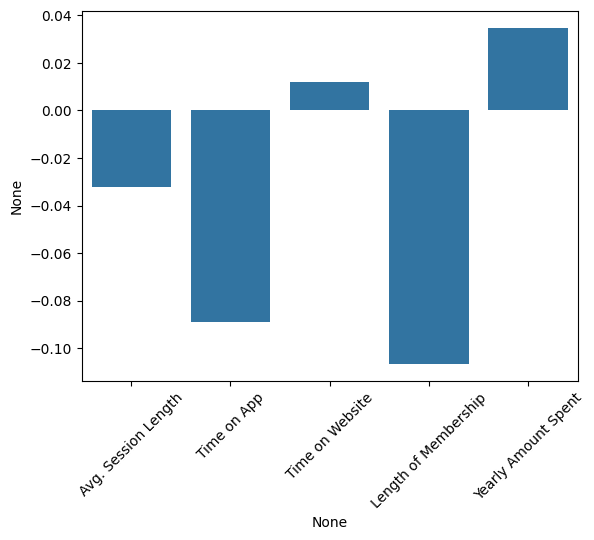

In [12]:
sns.barplot(x=data.columns, y=data.skew())
plt.xticks(rotation=45)
plt.show()

<b> Observations </b>
- There are very few outlir points in each columns but it dosen't look like a invalid data
- most of he columns are moderatly left skewd which shows the data is not symmetrical.

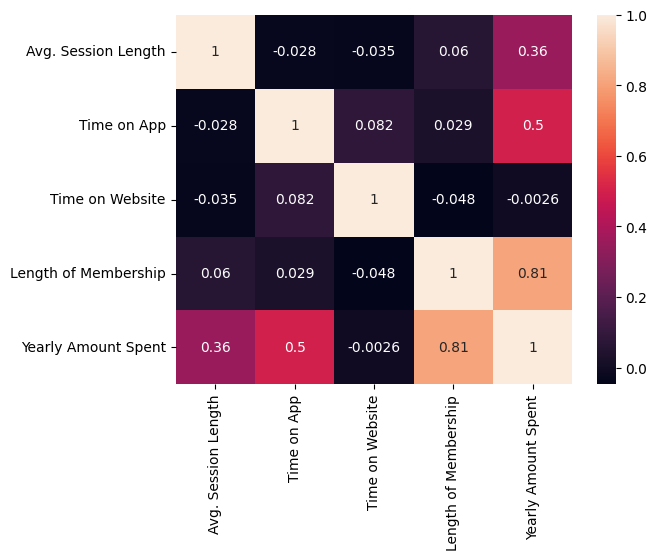

In [13]:
sns.heatmap(data.corr(), annot=True)
plt.show()

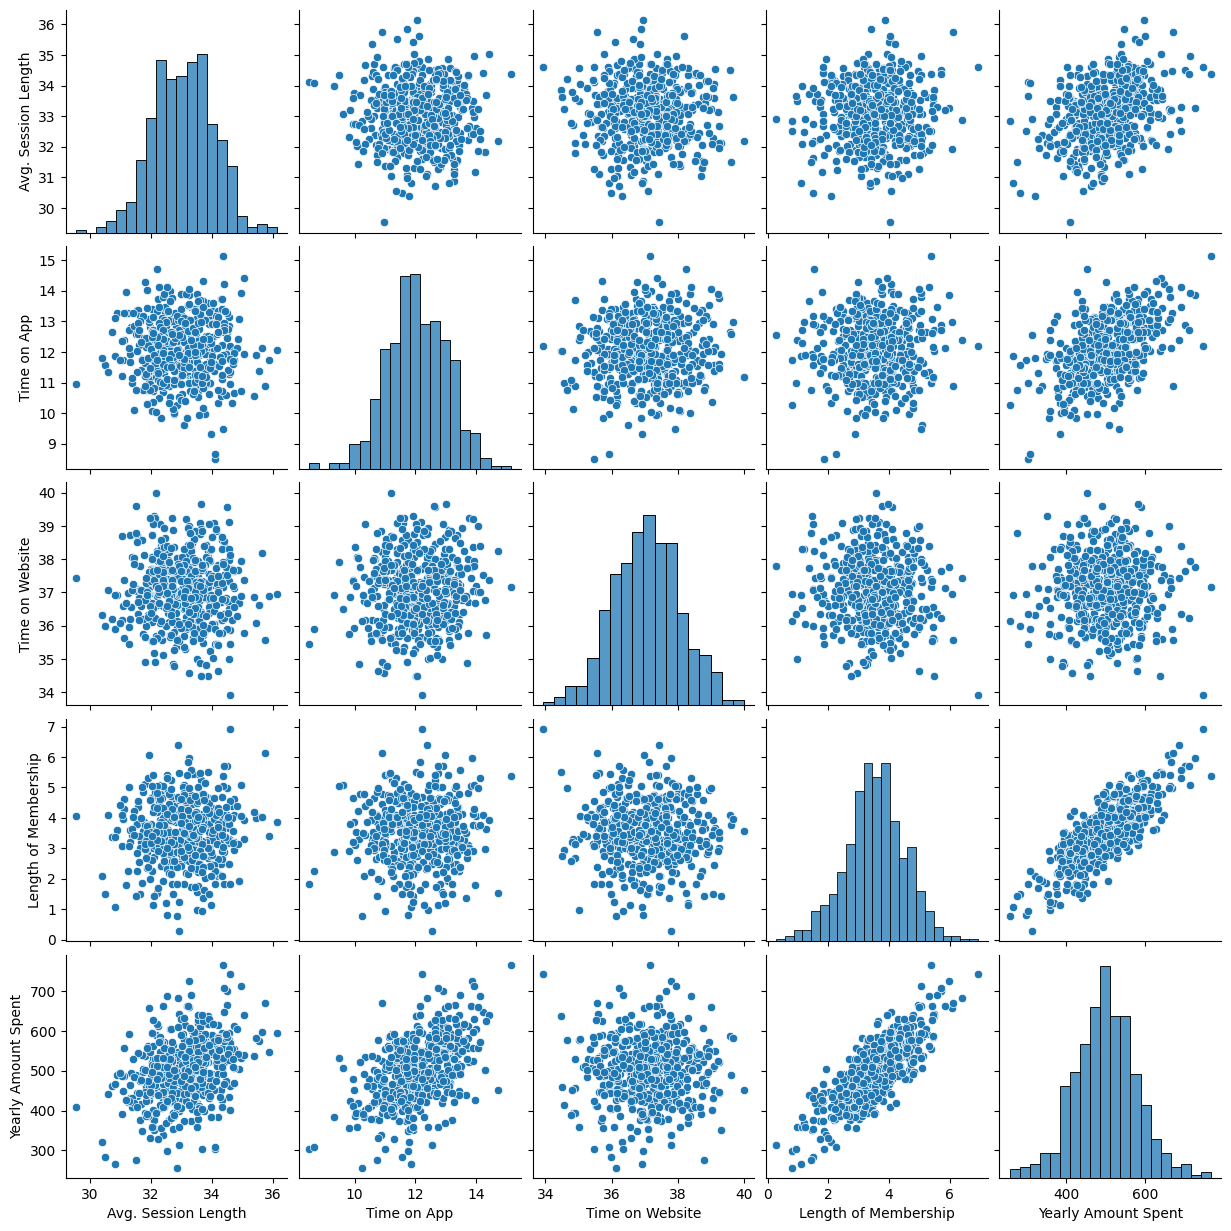

In [14]:
sns.pairplot(data)
plt.show()

<b> conclusion</b>
- If we take Yearly amount spent as a target parameter then it's celarly visible that it is linearly correlated with length of membership and time spent on app
- it shows a moderate correlation with Avg. Session length.

# Aim of this analysis :
 - The company is trying to decide whether to focus their efforts on their mobile app experience or their website.

Let's do Hypothesis Test for it


<b> H0 - Null Hypothesis </b>
- Advancement of App has no impact on yearly spent by the user

<b> H1 - Alternet Hypothesis </b>
- Advancement of App has a positive impact on yearly spent by the user

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error,mean_squared_error

In [18]:
y = data['Yearly Amount Spent']
X = data.drop(columns=['Yearly Amount Spent'])

In [19]:
import statsmodels.api as sm
model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Yearly Amount Spent   R-squared (uncentered):                   0.998
Model:                             OLS   Adj. R-squared (uncentered):              0.998
Method:                  Least Squares   F-statistic:                          6.146e+04
Date:                 Thu, 05 Mar 2026   Prob (F-statistic):                        0.00
Time:                         12:14:53   Log-Likelihood:                         -2270.3
No. Observations:                  500   AIC:                                      4549.
Df Residuals:                      496   BIC:                                      4565.
Df Model:                            4                                                  
Covariance Type:             nonrobust                                                  
                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------

<b> conclusion :</b>
- P values for every parameter is 0 that means these are the relevant parameters for the model
- Prob(F-statistics) is 0 that means the parameters used in hypothesis are relivant with Yearly Amount Spent so we can reject the Null Hypothesis

<b> Parameters Study :</b>
cofficients are positve except time on website, std err is minimal(Stable estimate), t-stat is positive and far from 0 and P value is 0 , Enough evidance that the parameter is relevant and able to reject H0
Kurtosis is near to ~3 Mesokurtic that shows the resedual distribution is normal


# Conclusion
So if the company put the efforts on App and the Length of Membership which means the user experice that will give a significant amount of growth 

In [27]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
l_r = LinearRegression()
l_r.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_pred = l_r.predict(x_test)

In [30]:
l_r.score(x_test, y_test)

0.9778130629184127

Text(0, 0.5, 'Predicted')

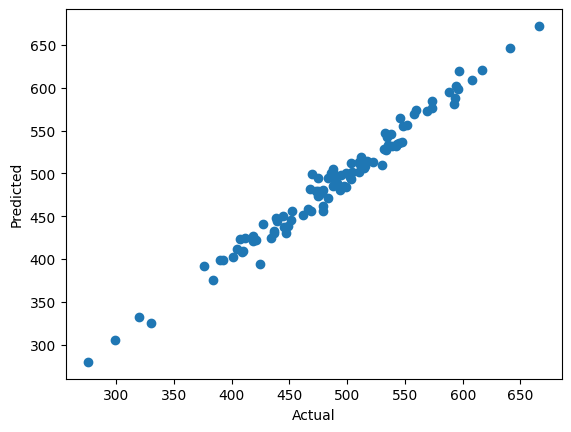

In [32]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [33]:
l_r.coef_

array([25.5962591 , 38.78534598,  0.31038593, 61.89682859])

In [38]:
r2_score(y_test,y_pred)

0.9778130629184127

In [39]:
root_mean_squared_error(y_test,y_pred)

10.481590584636454

In [41]:
mean_squared_error(y_test,y_pred)

109.86374118393957

In [42]:
mean_absolute_error(y_test,y_pred)

8.558441885315203

<b> The Scores are as expected, we have outliers so MSE will be high but RMSE and MAE tells thet the error is not so heigh that means the R-squared score is not a result of overfitting but the genuine variance defined by the input parameters also cofficent is clearly telling that length of membersip is the most important parameter to define the output.

- So if the busniess focus more on App experience then it may get more amount spent by the customer.